# HW 14 - Astropy
ULAB - Physics and Astronomy Division \
Due **Sunday, March 1st, 2025 at 11:59pm** on Gradescope

## 1 Unit Conversion
Import the astropy module `units` as `u` in the cell below.

In [313]:
import astropy.units as u

Convert a speed of **60 km/h** to **m/s**. \
\
Round your answer to two significant digits. *Hint: With an f-string, you can use `:.3f`, like `print(f"{speed_mps:.3f}")`*.

In [315]:
#defining speed in km/h and then using .to to convert from km/h to m/s
speedkmh = 60 * u.km / u.h
speedms = speedkmh.to(u.m / u.s)
print(f"{speedms:3f}")

16.666667 m / s


## 2 Time Manipulation
Define **Julian Date** in the cell below.

The Julian Date is a measure of the days since January 1, 4713 BCE at 12 noon from the Julian Calendar.

What's the difference between the **Julian calendar** and the **Gregorian calendar**?

The difference between the Julian calendar and the Gregorian calendar is that the Julian calendar had a leap every 4 years, while the Gregorian calendar has a leap more mostly every 4 years. The Gregorian calendar accounts for the fact that a leap year only happens when the century years are divisible by 400, and not every single 4 years.

From the astropy module `time` import `Time` in the cell below.

In [321]:
from astropy.time import Time

Find the Julian Date for **the current time**. 

In [323]:
#Time.now() defines the current Julian Date
current_time = Time.now()
print(f"The current Julian Date is {current_time.jd:.5f}.")

The current Julian Date is 2460744.71668.


Convert `1969-07-02 20:17:00` to its **Julian Date**.

In [325]:
date = Time("1969-07-02 20:17:00")
print(f"The Julian Date of the listed date is {date.jd:.5f}.")

The Julian Date of the listed date is 2440405.34514.


What historically happened at this date and time?

On this date and time, the Apollo 11 mission finished its preparations for the launch of the mission that sent humans to the moon.

## 3 Coordinate Transformations
From the astropy module `coordinates` import `SkyCoord`, `Galactic`, `AltAz` and `EarthLocation` in the cell below.

In [329]:
from astropy.coordinates import SkyCoord, Galactic, AltAz, EarthLocation

Define a celestial object at **RA = 15 degrees** and **DEC = -20 degrees** in ICRS. Use the astropy `Time` module.

In [331]:
#defining celestial object coordinates using SkyCoord. SkyCoord takes ra and dec, and defaults to ICRS as frame
celestial_object_icrs = SkyCoord(ra = 15 * u.deg, dec = -20 * u.deg)

Convert the object's coordinates from ICSRS to **Galactic**.

In [333]:
#transform_to(Galactic()) transforms the coordinates from ICRS to Galactic
celestial_object_galactic = celestial_object_icrs.transform_to(Galactic())
print(f"The Galactic coordinates of the celestial object are: l = {celestial_object_galactic.l}, b = {celestial_object_galactic.b}.")

The Galactic coordinates of the celestial object are: l = 138.7612378253739 deg, b = -82.60718782325382 deg.


Convert the object's coordinate from ICRS to **AltAz**. For AltAz frame, use the location of **Campbell Hall**.

In [335]:
#defining campbell hall's lat and lon coordinates to use as frame
campbell_hall = EarthLocation(lat = 37.8732 * u.deg, lon = -122.2573 * u.deg, height = 88 * u.m)

#creating the AltAz frame
current_time = Time.now()
altaz_frame = AltAz(obstime = current_time, location = campbell_hall)

#transforming coordinates from ICRS to AltAz
celestial_object_altaz = celestial_object_icrs.transform_to(altaz_frame)
print(f"The AltAz coordinates of the celestial object are: {celestial_object_altaz}.")

The AltAz coordinates of the celestial object are: <SkyCoord (AltAz: obstime=2025-03-10 05:12:01.418334, location=(-2690574.77008316, -4263099.26612269, 3894397.7921566) m, pressure=0.0 hPa, temperature=0.0 deg_C, relative_humidity=0.0, obswl=1.0 micron): (az, alt) in deg
    (264.59934813, -26.43509325)>.


## 4 FITS Files
From the astropy module `astropy.io` import `fits` in the cell below.

In [337]:
from astropy.io import fits

From the astropy module `astropy.utils.data` import `download_file`.

In [339]:
from astropy.utils.data import download_file

Import `numpy` in the cell below.

In [341]:
import numpy as np

Use the `download_file` astropy function to create a variable for the location of the `.fits` file from class.

In [343]:
image_file = download_file('http://data.astropy.org/tutorials/FITS-images/HorseHead.fits', cache=True)

Follow the procedure from lecture to open the `.fits` files in the cell below. Make sure to use the `hdul` format, while calling `hdul.info`, `hdul[0]` and `hdul[1]` appropriately.

In [345]:
hdul = fits.open(image_file)
hdul.info()
#cannot figure out how to move past this point.

OSError: No SIMPLE card found, this file does not appear to be a valid FITS file. If this is really a FITS file, try with ignore_missing_simple=True

With the `np.max` function, find the brightest pixel in the image. Print its value in the cell below.

In [ ]:
# Your code here

With the `np.min` function, find the least brightest pixel in the image. Print its value in the cell below.

In [ ]:
# Your code here

## Tables
From the astropy module `astropy.table` import `Table`.

In [357]:
from astropy.table import Table

Make an astropy table with **three** actual stars (so you will need to use google for this part). Include the `name`, `magnitude` and `spectral type`.

In [360]:
#defining stars and their data
stars = {
    "Name": ["Betelgeuse", "Theta1 Orionis C", "Polaris"],
    "Magnitude": [0.50, 5.13, 2.00],
    "Spectral Type": ["M2Iab", "O7V", "F7Ib-II"]
}

#creating the astropy table
stars_table = Table(stars)
print(stars_table)

      Name       Magnitude Spectral Type
---------------- --------- -------------
      Betelgeuse       0.5         M2Iab
Theta1 Orionis C      5.13           O7V
         Polaris       2.0       F7Ib-II


Save the table as a `.fits` file. *Hint: Use the function `.write` with the argument `format='fits'`.*

In [367]:
filename = "stars_table.fits"
stars_table.write(filename, format="fits", overwrite=True)

Read and print the table in the cell below from the `.fits` file you made.

In [370]:
table = Table.read(filename, format="fits")
print(table)

      Name       Magnitude Spectral Type
---------------- --------- -------------
      Betelgeuse       0.5         M2Iab
Theta1 Orionis C      5.13           O7V
         Polaris       2.0       F7Ib-II


## 6 Advanced... but awesome!
With the Hipparcos catalog, construct a Hertzsprung-Russell (H-R) diagram. Overall you will do the following:
* Download and clean the stellar data from the Hipparcos catalog.
* Calculate the absolute magnitude of the stars.
* Convert and classify spectral types.
* Plot an H-R diagram using both spectral class and color-index (B-V).

In the cell below, define what an **H-R** diagram is.

An HR diagram is a graph that shows the relationship between the absolute magnitude (luminosity) of stars and their corresponding surface temperature. A key feature is that the x-axis decreases as you go to the right, meaning that the hottest stars are those on the left part of the graph. Furthermore, there is a "main sequence" that we see on the HR diagram, which is a diagonal line that spans from the top left, where stars are hotter and more luminous, to the bottom right, where stars are cooler and less luminous. These are the stars that are burning hydrogen at their core, and where most stars spend their lifetimes. 

### 6.1 Download and Load in the Hipparcos Catalog
The catalog you are downloading contains accurate parallax measurements which will help us determine the **absolute magnitude** of stars. 
* **Absolute mangitude** = the actual brightness of a star
* **Apparent magnitude** = how bright the star appears to us on Earth

Import `pandas` in the cell below.

In [375]:
import pandas as pd

In the cell below import the file `cluster_data.csv` as a pandas dataframe. Add the following arguments:
* skiprows=44
* sep=';'
* header=None
* index_col=0
* names = ['HIP', 'Vmag', 'Plx', 'B-V', 'SpType']
* skipfooter=1
* engine='python'

In [378]:
#getting the file name
file = "cluster_data.tsv"

#creating the dataframe with the arguments above
df = pd.read_csv(file, skiprows=44, sep=";", header=None, index_col=0, names=["HIP", "Vmag", "Plx", "B-V", "SpType"], skipfooter=1, engine="python")

Display the first few rows of the data.

In [380]:
df.head()

,Vmag,Plx,B-V,SpType
HIP,,,,
10,8.59,10.76,0.489,F6V
11,7.34,4.29,0.081,A2
12,8.43,4.06,1.484,K4III
13,8.80,3.49,1.128,K0III
14,7.25,5.11,1.200,K0


### 6.2 Clean the Data
Some of the rows in the data contain **missing** or **invalid** values so we need to "clean" our data. We will start by replacing the **blank spaces with NaN**, run the cell below.

In [382]:
#df_clean = df.applymap(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)
#the above line doesn't work since df has been deprecated, so we replace df.applymap with df.map
df_clean = df.map(lambda x: np.nan if isinstance(x, str) and x.isspace() else x)

Drop the rows with missing (NaN) values. *Hint: Use the `.dropna()` function`.

In [387]:
df_clean = df_clean.dropna()

Run the cell below. We are converting the datatypes in the columns to floats.

In [390]:
df_clean[['Vmag', 'Plx', 'B-V']] = df_clean[['Vmag', 'Plx', 'B-V']].astype(float)

# Display dataset summary
print(df_clean.describe())

                Vmag            Plx            B-V
count  114463.000000  114463.000000  114463.000000
mean        8.297699       7.104872       0.702415
std         1.248614      11.064009       0.490235
min        -1.440000     -35.100000      -0.400000
25%         7.610000       2.520000       0.341000
50%         8.400000       4.580000       0.605000
75%         9.070000       8.260000       1.075000
max        13.610000     772.330000       5.460000


### 6.3 Compute Absolute Magnitude
The absolute magnitude ($M_V$) of a star is given by:

$$
M_V = V_{\text{mag}} + 5 \cdot \log_{10}\left(\frac{\text{Plx}}{100}\right)
$$

Run the cell below.

In [393]:
df_clean['M_V'] = df_clean['Vmag'] + 5 * np.log10(df_clean['Plx'] / 100)
print(df_clean[['Vmag', 'Plx', 'M_V']].head())

     Vmag    Plx       M_V
HIP                       
10   8.59  10.76  3.749061
11   7.34   4.29  0.502286
12   8.43   4.06  1.472630
13   8.80   3.49  1.514127
14   7.25   5.11  0.792105


C:\Users\emili\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
C:\Users\emili\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


Describe what the cell above is doing. 

The above cell computes the absolute magnitude of the stars following the equation above, and then storing them in a new column labeled "M_V" in the df_clean dataframe. 

### 6.4 Process the Spectral Types
Stars are defined by their spectral types:
* The first letter (O, B, A, F, G, K, M) indicates the **temperature** of a star.
* The digit (0-9) refines the **classification**.

Now we will extract the first two characters for sorting purposes. Run the cell below.

In [398]:
# Extract the first two characters (e.g., 'G2', 'K3')
df_clean['SpType2'] = df_clean['SpType'].str[:2]

# Keep only valid spectral classes
df_clean = df_clean[df_clean['SpType2'].str.match(r'^[OBAFGKM][0-9]')]

# Display unique spectral types
print(df_clean['SpType2'].unique())

['F6' 'A2' 'K4' 'K0' 'K2' 'F3' 'K5' 'G5' 'G0' 'G8' 'F2' 'G3' 'F7' 'A0'
 'B8' 'F0' 'G6' 'G9' 'K1' 'K3' 'F5' 'G1' 'A4' 'G2' 'B5' 'B9' 'M0' 'F8'
 'M1' 'G7' 'M2' 'B0' 'B7' 'A9' 'M3' 'A3' 'O7' 'A1' 'B4' 'A6' 'B3' 'B2'
 'A5' 'M4' 'A7' 'O8' 'M5' 'G4' 'K7' 'B1' 'O6' 'M6' 'F4' 'A8' 'K8' 'M7'
 'B6' 'O9' 'F9' 'M8' 'M9' 'K9' 'O5' 'F1' 'K6' 'O4']


What letter represents the **hottest** stars? What letter represents the **coldest** stars?

The hottest stars are represented by the letter O, and the coldest stars are represented by the letter M. OBAFGKM is the order of stars from hottest to coolest. 

### 6.5 Plot the H-R Diagram(s)
Conver the spectral types into sortable numerical categories. Run the cell below.

In [403]:
order = {'O': 0, 'B': 1, 'A': 2, 'F': 3, 'G': 4, 'K': 5, 'M': 6}
df_clean['SpType2_numeric'] = df_clean['SpType2'].apply(lambda x: order[x[0]]*10 + int(x[1]))

Import `matplotlib.pyplot` in the cell below.

In [406]:
import matplotlib.pyplot as plt

**Spectral Type vs. Absolute Magnitude** \
Scatter the `df_clean['SpType2_numeric']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(0, 70).
* Set a `ylim` of `(15, -10).
* Call `xticklabels(['O', 'B', 'A', 'F', 'G', 'K', 'M'])`.
* Call `xticks(range(5,75,10))`.
* Title the x-axis `'Spectral Type'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

Text(0.5, 1.0, 'H-R Diagram (Hipparcos catalog)')

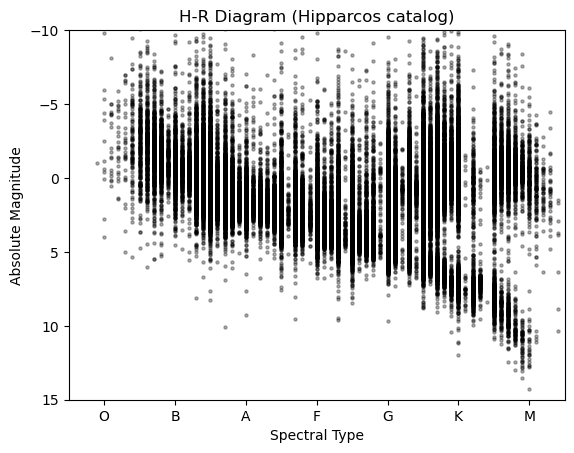

In [409]:
#scatter the data
plt.scatter(df_clean["SpType2_numeric"], df_clean["M_V"], s=5, alpha=0.3, c="k")

#put limits on our x and y axes
plt.xlim(0, 70)
plt.ylim(15, -10)

#replace x-axis with ticks represented by the different spectral types as shown, and label the diagram
plt.xticks(range(5, 75, 10), ['O', 'B', 'A', 'F', 'G', 'K', 'M'])
plt.xlabel("Spectral Type")
plt.ylabel("Absolute Magnitude")
plt.title("H-R Diagram (Hipparcos catalog)")

**Color Index (B-V) vs. Absolute Magnitude** \
Scatter the `df_clean['B-V']` on the x-axis and the `df_clean['M_V']` on the y-axis. Add the following features:
* In the `plt.scatter` function, give arguments of: `s=5`, `alpha=0.3` and `c='k'`.
* Set a `xlim` of `(-0.5, 2.5).
* Set a `ylim` of `(15, -10).
* Title the x-axis `'Color Index (B-V)'`.
* Title the y-axis `Absolute Magnitude`.
* Give a title of `H-R Diagram (Hipparcos catalog)`.

Text(0.5, 1.0, 'H-R Diagram (Hipparcos catalog)')

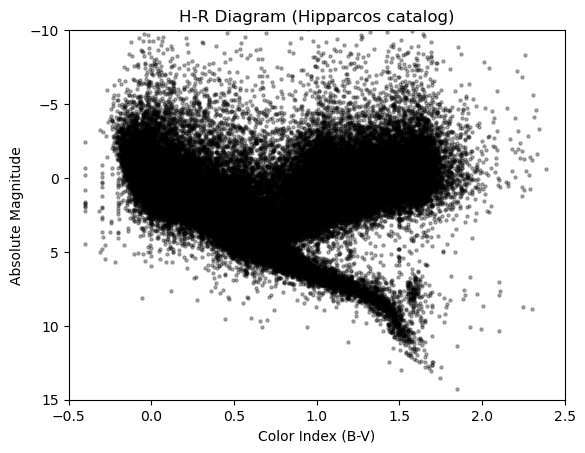

In [412]:
plt.scatter(df_clean["B-V"], df_clean["M_V"], s=5, alpha=0.3, c="k")
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel("Color Index (B-V)")
plt.ylabel("Absolute Magnitude")
plt.title("H-R Diagram (Hipparcos catalog)")

### 6.6 Highlight Luminosity Classes
Great! Finally, we want to difference between our three main luminosity classes:
* Main Sequence (V), aka what our sun is
* Giants (III)
* Supergiants(I)

Run the cell below.

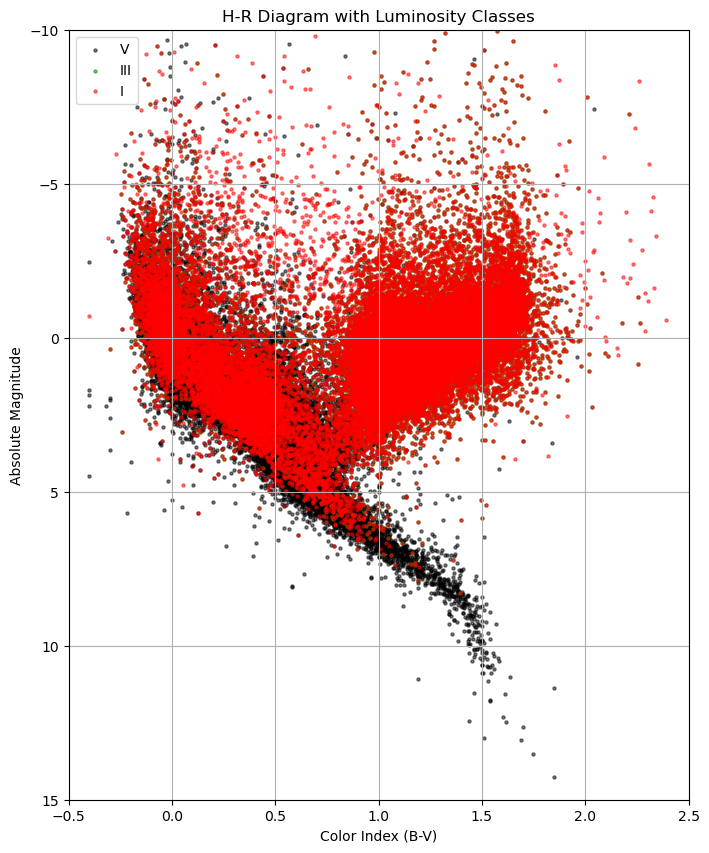

In [415]:
def plot_luminosity_class(df, label, color):
    mask = df['SpType'].str.contains(label, na=False)
    plt.scatter(df[mask]['B-V'], df[mask]['M_V'], s=5, label=label, c=color, alpha=0.5)

plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with Luminosity Classes')

plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants

plt.legend()
plt.show()

With the example above, now plot the following types **WITH** and then **WITHOUT** the ones above:
* Subdwarfs (VI)
* White dwarfs (VII)
* Subgiants (IV)
* Bright giants (II)

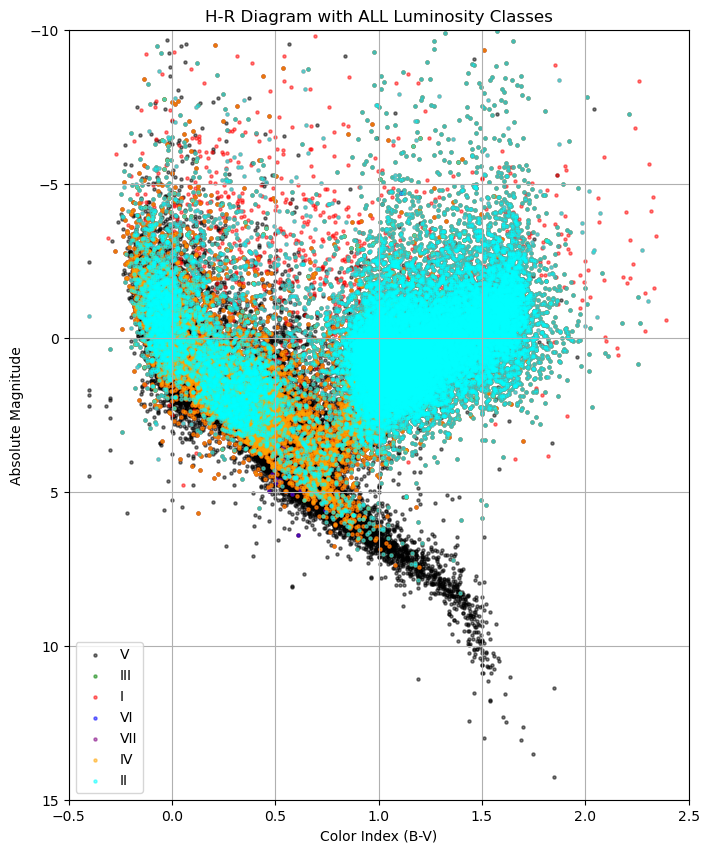

In [417]:
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with ALL Luminosity Classes')

#plotting the different spectral types, with ALL the spectral types
plot_luminosity_class(df_clean, 'V', 'black')  # Main Sequence
plot_luminosity_class(df_clean, 'III', 'green')  # Giants
plot_luminosity_class(df_clean, 'I', 'red')  # Supergiants
plot_luminosity_class(df_clean, 'VI', 'blue')
plot_luminosity_class(df_clean, 'VII', 'purple')
plot_luminosity_class(df_clean, 'IV', 'orange')
plot_luminosity_class(df_clean, 'II', 'cyan')

plt.legend()
plt.show()

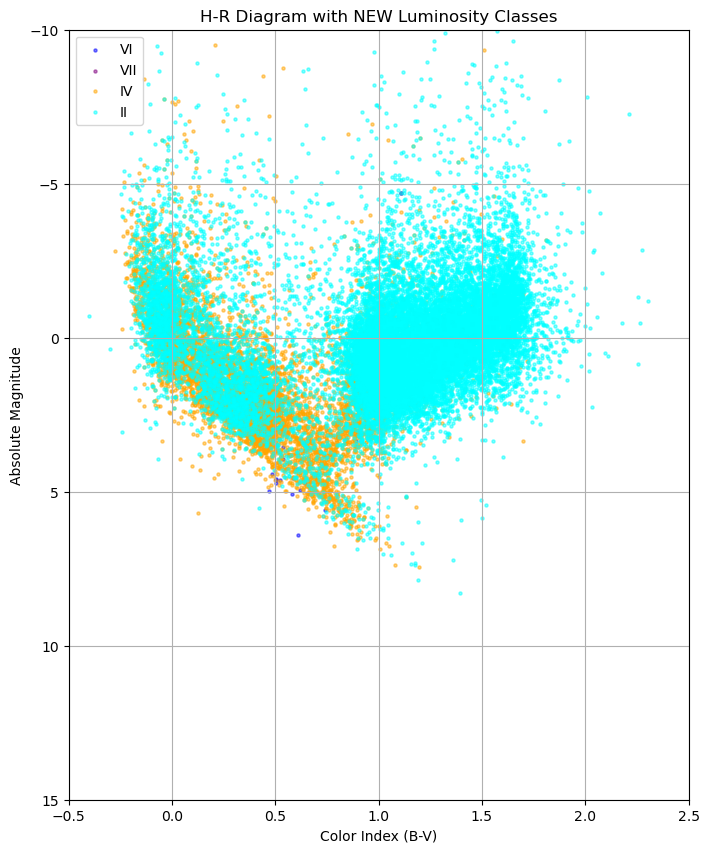

In [419]:
plt.figure(figsize=(8,10))
plt.grid()
plt.xlim(-0.5, 2.5)
plt.ylim(15, -10)
plt.xlabel('Color Index (B-V)')
plt.ylabel('Absolute Magnitude')
plt.title('H-R Diagram with NEW Luminosity Classes')

#plotting the different spectral types, with the NEW spectral types above
plot_luminosity_class(df_clean, 'VI', 'blue')
plot_luminosity_class(df_clean, 'VII', 'purple')
plot_luminosity_class(df_clean, 'IV', 'orange')
plot_luminosity_class(df_clean, 'II', 'cyan')

plt.legend()
plt.show()

Submit your FITS file and this notebook to Gradescope!